In [ ]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans


%matplotlib inline

In [ ]:
df = pd.read_csv("/content/Mall_Customers_generated.csv")

In [ ]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,35,37,99
1,2,Female,35,42,5
2,3,Female,52,100,44
3,4,Male,28,49,44
4,5,Female,62,77,21
...,...,...,...,...,...
495,496,Male,29,102,86
496,497,Female,64,110,46
497,498,Female,44,134,35
498,499,Male,19,123,38


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,35,37,99
1,2,Female,35,42,5
2,3,Female,52,100,44
3,4,Male,28,49,44
4,5,Female,62,77,21


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              500 non-null    int64 
 1   Gender                  500 non-null    object
 2   Age                     500 non-null    int64 
 3   Annual Income (k$)      500 non-null    int64 
 4   Spending Score (1-100)  500 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 19.7+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,500.000000,500.00000,500.000000,500.000000
mean,250.500000,43.19800,82.016000,50.770000
std,144.481833,15.15897,39.881334,29.168385
min,1.000000,18.00000,15.000000,1.000000
25%,125.750000,30.00000,46.750000,25.000000
50%,250.500000,42.00000,80.000000,50.000000
75%,375.250000,57.00000,116.250000,76.000000
max,500.000000,70.00000,150.000000,100.000000


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (500, 5)


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
455,456,Male,38,27,18
496,497,Female,64,110,46
306,307,Female,59,120,32
362,363,Male,23,135,32
83,84,Female,57,86,25
295,296,Male,38,115,81
361,362,Male,68,131,41
353,354,Male,26,56,80
87,88,Female,27,141,18
71,72,Female,60,142,94


In [ ]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


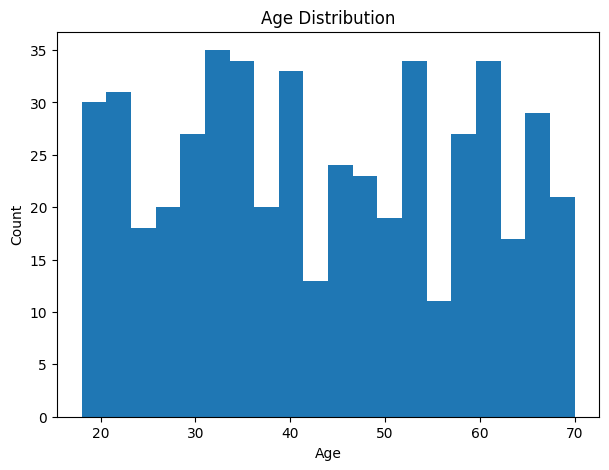

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

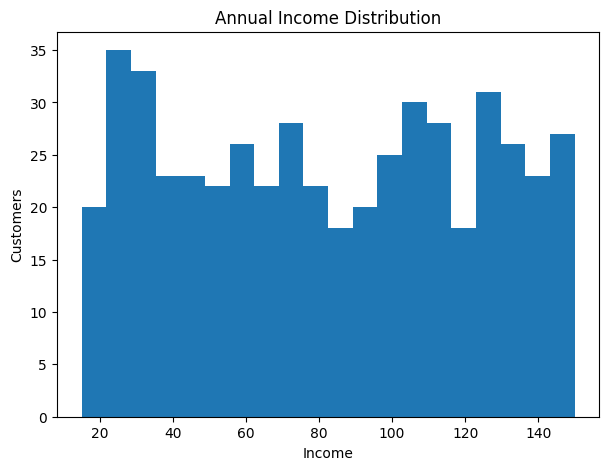

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(df["Annual Income (k$)"], bins=20)

plt.title("Annual Income Distribution")

plt.xlabel("Income")

plt.ylabel("Customers")

plt.show()

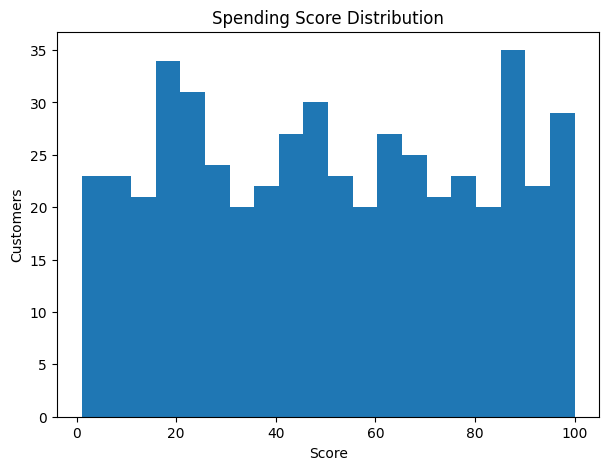

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(df["Spending Score (1-100)"], bins=20)

plt.title("Spending Score Distribution")

plt.xlabel("Score")

plt.ylabel("Customers")

plt.show()

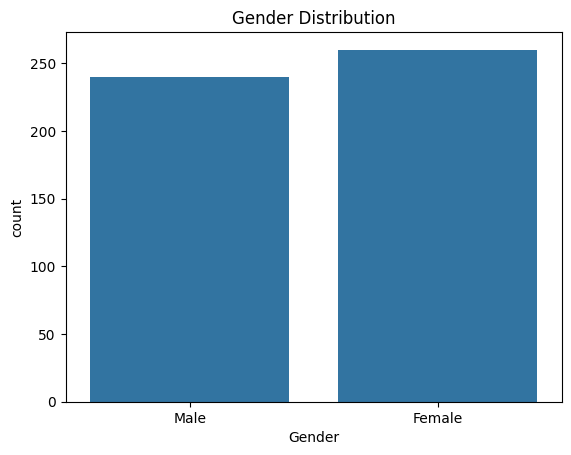

In [ ]:
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

In [ ]:
df_corr = df.copy()

df_corr["Gender"] = df_corr["Gender"].map({"Male":1,"Female":0})

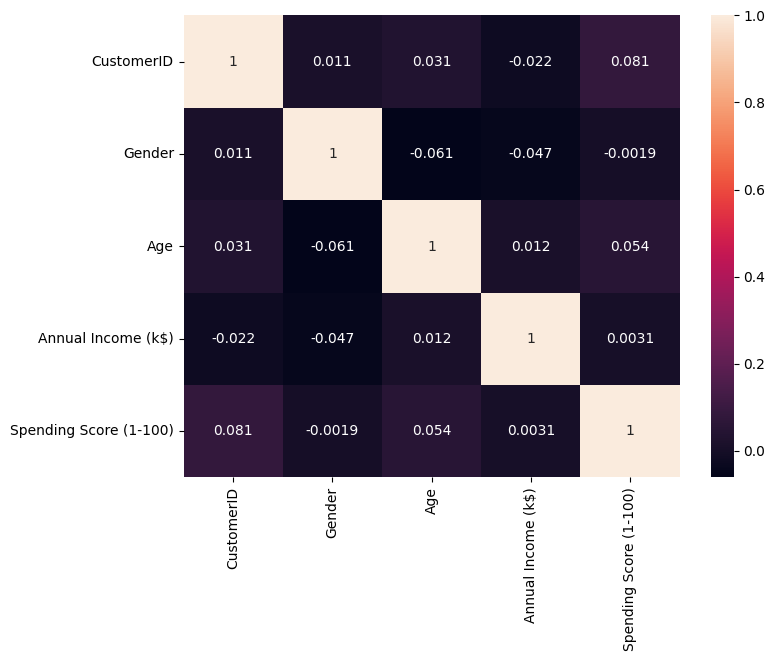

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df_corr.corr(), annot=True)

plt.show()

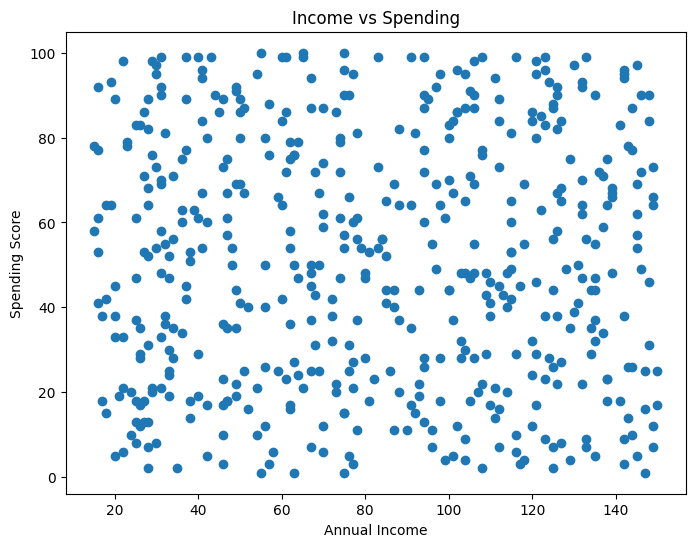

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df["Annual Income (k$)"],

            df["Spending Score (1-100)"])

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Income vs Spending")

plt.show()

In [ ]:
X = df[["Annual Income (k$)",

        "Spending Score (1-100)"]]

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

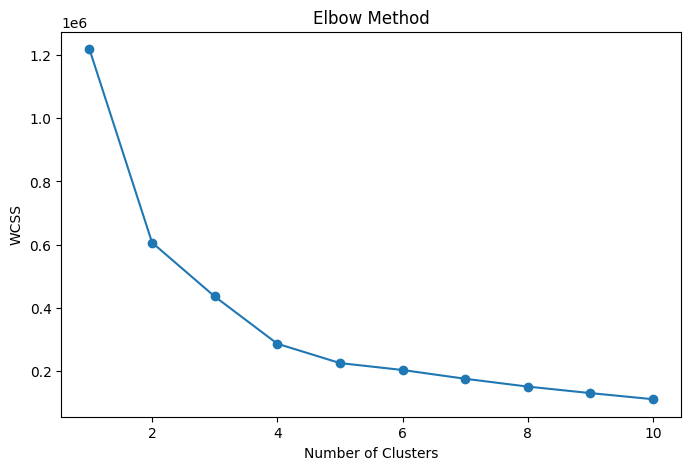

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5,

                random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,35,37,99,3
1,2,Female,35,42,5,0
2,3,Female,52,100,44,2
3,4,Male,28,49,44,0
4,5,Female,62,77,21,2


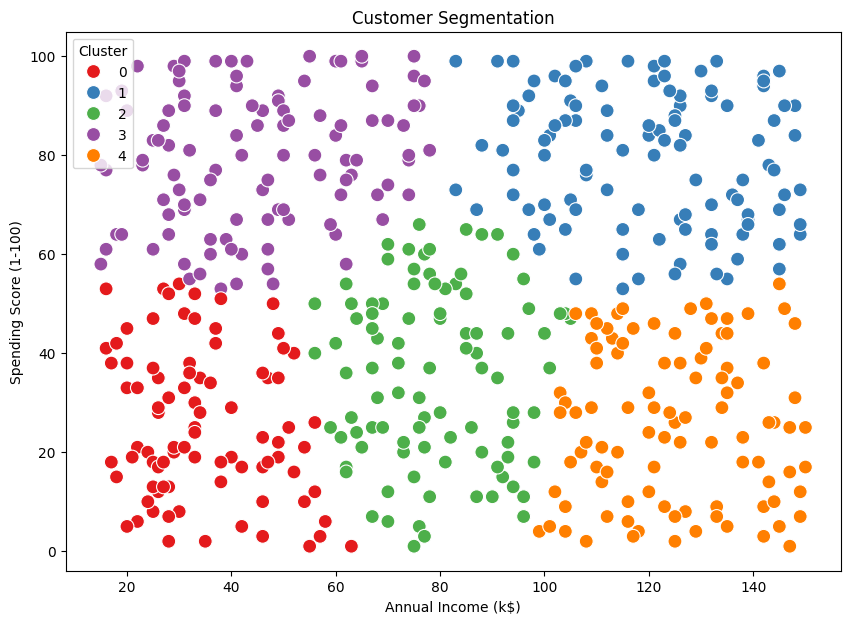

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(

x="Annual Income (k$)",

y="Spending Score (1-100)",

hue="Cluster",

palette="Set1",

data=df,

s=100

)

plt.title("Customer Segmentation")

plt.show()

In [ ]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,237.298851,42.896552,34.827586,25.482759
1,256.770642,43.944954,119.568807,79.018349
2,269.948454,43.896907,79.309278,35.556701
3,264.694444,43.425926,45.120370,79.203704
4,220.656566,41.707071,125.040404,25.777778


In [ ]:
df.to_csv("Customer_Segmentation_Result.csv", index=False)

print("File Saved Successfully")

File Saved Successfully
